<a href="https://colab.research.google.com/github/Shawaiz-Project/Data-Analyst/blob/Level-1/1_Day_E_Commerce_Cohort_Retention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Cohort Retention Analysis

## 1. Project Overview

**E-Commerce Cohort Retention Analysis** is a customer retention analytics project designed to understand how customer cohorts behave over time.

### Business Problem

Increasing Customer Acquisition Cost (CAC) and limited visibility into customer retention patterns make it difficult to determine whether newly acquired customers continue to purchase.

### Objective

Build a **monthly cohort retention analysis** to understand customer behavior over time, compare different acquisition cohorts, and identify whether recent cohorts are performing better or worse than historical cohorts.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset

**UCI Online Retail Dataset**

The dataset contains approximately **500,000 e-commerce transactions**.

---

## 2. Business Problem

The company acquires many new customers who make a single purchase and never return. This increases the effective **Customer Acquisition Cost (CAC)** and reduces customer lifetime value.

The analysis aims to quantify customer retention by cohort and determine:

- How many customers return after their first purchase
- How retention changes over subsequent months
- Which customer cohorts perform best and worst
- Whether recent cohorts have weaker retention than historical cohorts
- Whether revenue retention tells the same story as customer retention

---

## 3. Business Objectives

The project focuses on the following objectives:

1. Clean and prepare the raw transactional data.
2. Assign each customer to an acquisition cohort based on their first purchase month.
3. Calculate monthly customer retention percentages.
4. Visualize cohort retention using heatmaps.
5. Compare older and newer customer cohorts.
6. Extend the analysis to revenue retention.
7. Identify actionable business recommendations based on the findings.

---

## 4. Business Questions

The analysis is designed to answer the following questions:

- What percentage of customers return after **1, 2, 3, 6, and 12 months**?
- Where does the largest customer drop-off occur?
- Which cohorts have the strongest retention?
- Which cohorts have the weakest retention?
- Are recent customer cohorts performing worse than historical cohorts?
- Does revenue retention tell the same story as customer retention?
- Should the company focus more on **customer acquisition or customer retention**?

---

## 5. Dataset Description

### UCI Online Retail Dataset

The **UCI Online Retail Dataset** contains transactional data from an online retail business.

### Dataset Columns

| Column | Description |
|---|---|
| `InvoiceNo` | Unique invoice/transaction number |
| `StockCode` | Product/item code |
| `Description` | Product description |
| `Quantity` | Number of items purchased |
| `InvoiceDate` | Date and time of the transaction |
| `UnitPrice` | Price per item |
| `CustomerID` | Unique customer identifier |
| `Country` | Customer's country |

### Dataset Size

- Approximately **500,000 transactions**
- Transaction-level e-commerce data
- Includes customer, product, quantity, price, and transaction date information

---

## 6. Cohort Analysis Approach

Each customer is assigned to a cohort based on the **month of their first purchase**.

For example:

| Customer | First Purchase | Cohort |
|---|---|---|
| Customer A | January 2011 | January 2011 |
| Customer B | February 2011 | February 2011 |
| Customer C | February 2011 | February 2011 |

Customers within the same cohort are then tracked across subsequent months to measure retention.

### Retention Calculation

Retention is calculated as:

```text
Retention Rate =
Number of Active Customers in a Cohort in Month N
--------------------------------------------------
Total Customers in the Cohort
× 100

In [2]:
# Environment & Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print('Libraries imported successfully.')
print(f'Pandas version: {pd.__version__}')


Libraries imported successfully.
Pandas version: 2.2.3


In [3]:

# Data Loading
# Download the dataset from UCI if not already present.
# The file is an Excel workbook.

import os
import urllib.request

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
data_path = 'Online_Retail.xlsx'

if not os.path.exists(data_path):
    print('Downloading dataset...')
    urllib.request.urlretrieve(url, data_path)
    print('Download complete.')
else:
    print('Dataset already exists.')

# Read the Excel file
df_raw = pd.read_excel(data_path)

print(f'Dataset loaded. Shape: {df_raw.shape}')
print(df_raw.head())


Dataset already exists.
Dataset loaded. Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [4]:
# Initial Data Inspection
print('\n--- Data Info ---')
df_raw.info()

print('\n--- First 5 rows ---')
df_raw.head()

print('\n--- Summary statistics for numeric columns ---')
df_raw.describe()

print('\n--- Missing values ---')
print(df_raw.isnull().sum())



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

--- First 5 rows ---

--- Summary statistics for numeric columns ---

--- Missing values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
# Data Quality Assessment
# Check for duplicates, negative quantities, invalid prices, cancellations.

print(f'\nDuplicate rows: {df_raw.duplicated().sum()}')

# Check quantity and price distributions
print('\nQuantity min, max:', df_raw['Quantity'].min(), df_raw['Quantity'].max())
print('UnitPrice min, max:', df_raw['UnitPrice'].min(), df_raw['UnitPrice'].max())

# Cancellations: invoices starting with 'C'
cancellations = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Number of cancellation invoices: {len(cancellations)}')



Duplicate rows: 5268

Quantity min, max: -80995 80995
UnitPrice min, max: -11062.06 38970.0
Number of cancellation invoices: 9288


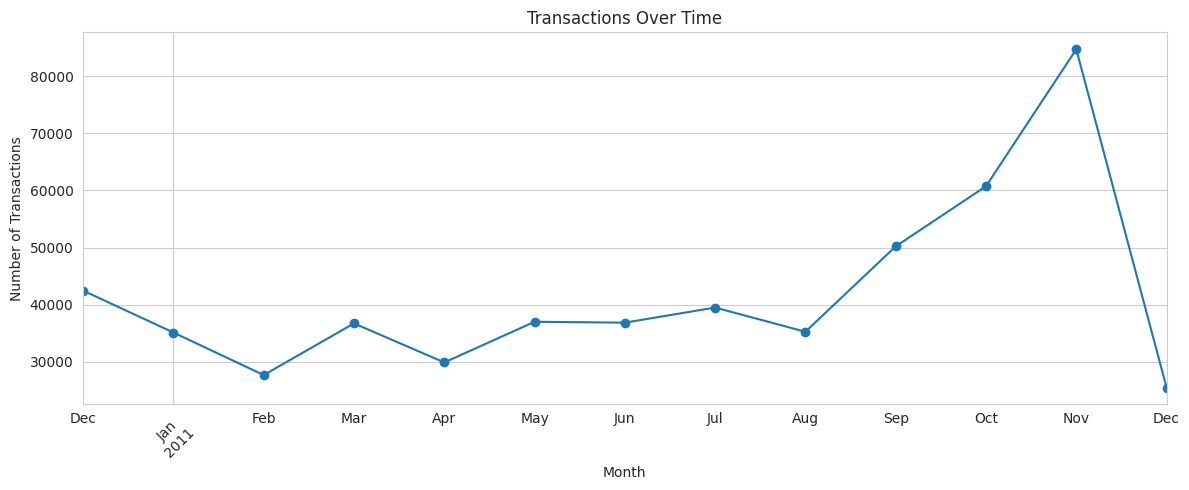

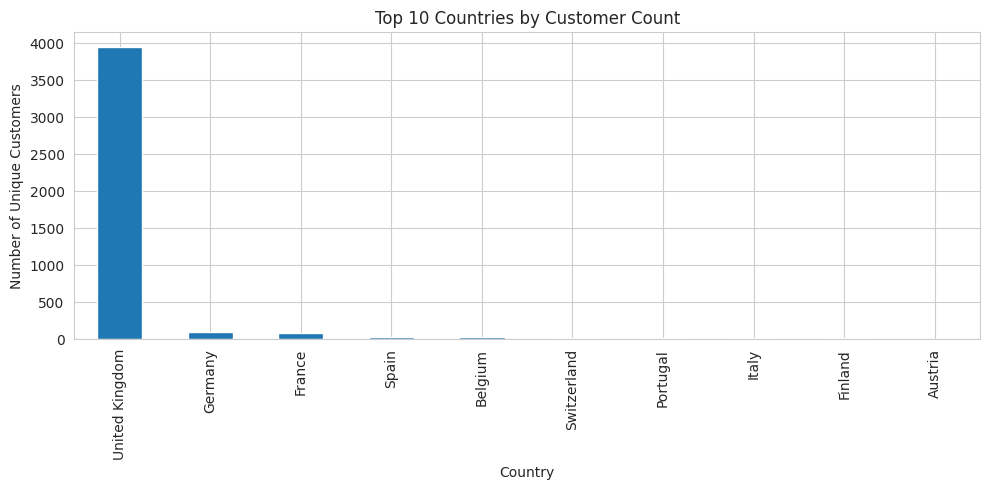

In [6]:

# -----------------------------------------------------------------------------
# 10. Exploratory Data Analysis
# -----------------------------------------------------------------------------
# We'll create a few key visualizations to understand the data.

# 1. Transactions over time
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['InvoiceMonth'] = df_raw['InvoiceDate'].dt.to_period('M')
transactions_by_month = df_raw.groupby('InvoiceMonth').size()

plt.figure(figsize=(12,5))
transactions_by_month.plot(kind='line', marker='o')
plt.title('Transactions Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Top countries by customer count
customers_by_country = df_raw.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
customers_by_country.plot(kind='bar')
plt.title('Top 10 Countries by Customer Count')
plt.xlabel('Country')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()

# 3. Top countries by revenue (using cleaned data later, but EDA can be approximate)
# We'll compute revenue for EDA only after cleaning? Actually, we can compute with current data but be aware of negatives.
# We'll compute revenue later properly.

# 4. Distribution of order revenue (we'll do after cleaning)
# 5. Customer purchase frequency (after cleaning)

# For now, we note the key insights.


In [7]:

# -----------------------------------------------------------------------------
# 11. Data Cleaning
# -----------------------------------------------------------------------------
# We will apply cleaning steps sequentially, documenting each decision.

# Step 1: Remove rows without CustomerID (cannot track customer-level retention)
df_clean = df_raw.dropna(subset=['CustomerID'])
print(f'Rows after dropping missing CustomerID: {df_clean.shape[0]}')

# Step 2: Remove cancellations (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Rows after removing cancellations: {df_clean.shape[0]}')

# Step 3: Remove rows with Quantity <= 0 (returns and negative quantities)
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f'Rows after removing non-positive Quantity: {df_clean.shape[0]}')

# Step 4: Remove rows with UnitPrice <= 0 (invalid prices)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f'Rows after removing non-positive UnitPrice: {df_clean.shape[0]}')

# Step 5: Remove exact duplicate rows (if any)
df_clean = df_clean.drop_duplicates()
print(f'Rows after dropping duplicates: {df_clean.shape[0]}')

# Check remaining rows
print(f'\nCleaned dataset shape: {df_clean.shape}')
print(df_clean.head())


Rows after dropping missing CustomerID: 406829
Rows after removing cancellations: 397924
Rows after removing non-positive Quantity: 397924
Rows after removing non-positive UnitPrice: 397884
Rows after dropping duplicates: 392692

Cleaned dataset shape: (392692, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country InvoiceMonth  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom      2010-12  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom      2010-12  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom      2010-12 

In [8]:

# -----------------------------------------------------------------------------
# 12. Data Validation (after cleaning)
# -----------------------------------------------------------------------------
# Verify that we have no negative quantities or prices, no cancellations, and CustomerID not null.
assert df_clean['Quantity'].min() > 0
assert df_clean['UnitPrice'].min() > 0
assert df_clean['CustomerID'].notnull().all()
assert not df_clean['InvoiceNo'].astype(str).str.startswith('C').any()

print('All validation checks passed.')


All validation checks passed.


In [9]:

# -----------------------------------------------------------------------------
# 13. Feature Engineering
# -----------------------------------------------------------------------------
# Create Revenue = Quantity * UnitPrice
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Ensure InvoiceDate is datetime (already done, but convert again if needed)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create InvoiceMonth as a Period (year-month)
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

print(df_clean[['InvoiceDate', 'InvoiceMonth', 'Revenue']].head())


          InvoiceDate InvoiceMonth  Revenue
0 2010-12-01 08:26:00      2010-12    15.30
1 2010-12-01 08:26:00      2010-12    20.34
2 2010-12-01 08:26:00      2010-12    22.00
3 2010-12-01 08:26:00      2010-12    20.34
4 2010-12-01 08:26:00      2010-12    20.34


In [10]:

# -----------------------------------------------------------------------------
# 14. Customer First Purchase
# -----------------------------------------------------------------------------
# For each customer, find the earliest InvoiceDate.
first_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']

# Merge back to main dataframe
df_cohort = df_clean.merge(first_purchase, on='CustomerID', how='left')

# Create CohortMonth (first purchase month)
df_cohort['CohortMonth'] = df_cohort['FirstPurchaseDate'].dt.to_period('M')

print(df_cohort[['CustomerID', 'InvoiceDate', 'FirstPurchaseDate', 'CohortMonth']].head())


   CustomerID         InvoiceDate   FirstPurchaseDate CohortMonth
0     17850.0 2010-12-01 08:26:00 2010-12-01 08:26:00     2010-12
1     17850.0 2010-12-01 08:26:00 2010-12-01 08:26:00     2010-12
2     17850.0 2010-12-01 08:26:00 2010-12-01 08:26:00     2010-12
3     17850.0 2010-12-01 08:26:00 2010-12-01 08:26:00     2010-12
4     17850.0 2010-12-01 08:26:00 2010-12-01 08:26:00     2010-12


In [11]:

# -----------------------------------------------------------------------------
# 15. Cohort Assignment
# -----------------------------------------------------------------------------
# Now every customer has a CohortMonth (acquisition cohort).

# -----------------------------------------------------------------------------
# 16. Cohort Index Calculation
# -----------------------------------------------------------------------------
# Compute the difference in months between InvoiceMonth and CohortMonth.
# Convert to integer.
df_cohort['CohortIndex'] = (df_cohort['InvoiceMonth'].dt.year - df_cohort['CohortMonth'].dt.year) * 12 + \
                           (df_cohort['InvoiceMonth'].dt.month - df_cohort['CohortMonth'].dt.month)

# Let's verify: CohortIndex should be 0 for the first purchase month.
assert (df_cohort[df_cohort['InvoiceDate'] == df_cohort['FirstPurchaseDate']]['CohortIndex'] == 0).all()
print('CohortIndex calculated correctly.')

print(df_cohort[['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex', 'Revenue']].head())


CohortIndex calculated correctly.
   CustomerID InvoiceMonth CohortMonth  CohortIndex  Revenue
0     17850.0      2010-12     2010-12            0    15.30
1     17850.0      2010-12     2010-12            0    20.34
2     17850.0      2010-12     2010-12            0    22.00
3     17850.0      2010-12     2010-12            0    20.34
4     17850.0      2010-12     2010-12            0    20.34


In [12]:

# -----------------------------------------------------------------------------
# 17. Monthly Active Customers
# -----------------------------------------------------------------------------
# For each cohort and each cohort index, count unique active customers.
# We'll create a pivot table.
cohort_data = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'ActiveCustomers']

# Also get the total cohort size (active at index 0)
cohort_sizes = cohort_data[cohort_data['CohortIndex'] == 0][['CohortMonth', 'ActiveCustomers']]
cohort_sizes.columns = ['CohortMonth', 'CohortSize']

# Merge to get cohort size per row
cohort_data = cohort_data.merge(cohort_sizes, on='CohortMonth', how='left')

# Calculate retention percentage
cohort_data['Retention'] = (cohort_data['ActiveCustomers'] / cohort_data['CohortSize']) * 100

print(cohort_data.head())


  CohortMonth  CohortIndex  ActiveCustomers  CohortSize   Retention
0     2010-12            0              885         885  100.000000
1     2010-12            1              324         885   36.610169
2     2010-12            2              286         885   32.316384
3     2010-12            3              340         885   38.418079
4     2010-12            4              321         885   36.271186


In [13]:

# -----------------------------------------------------------------------------
# 18. Customer Retention Calculation
# -----------------------------------------------------------------------------
# Already computed above: Retention = ActiveCustomers / CohortSize * 100

# -----------------------------------------------------------------------------
# 19. Retention Validation
# -----------------------------------------------------------------------------
# Check that Month 0 = 100% for all cohorts
assert (cohort_data[cohort_data['CohortIndex'] == 0]['Retention'] == 100.0).all()
print('Validation: Month 0 retention is 100% for all cohorts.')

# Check that missing future months are not present (we will handle in pivot)
# We'll create the pivot matrix with NaN for missing combinations.


Validation: Month 0 retention is 100% for all cohorts.


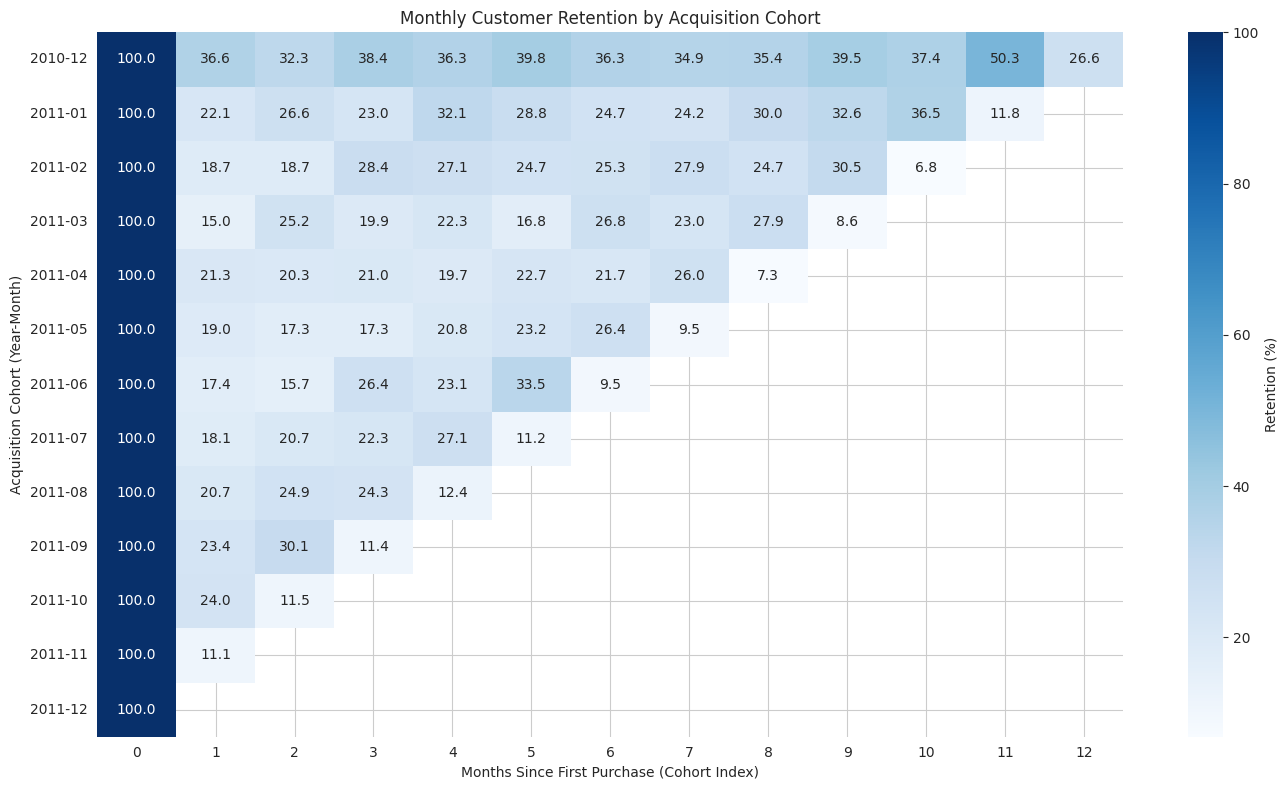

In [14]:

# -----------------------------------------------------------------------------
# 20. Customer Retention Heatmap
# -----------------------------------------------------------------------------
# Pivot the data to create a matrix: rows = CohortMonth, columns = CohortIndex, values = Retention
retention_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Retention')

# Sort rows chronologically
retention_pivot = retention_pivot.sort_index()

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention_pivot, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Retention (%)'})
plt.title('Monthly Customer Retention by Acquisition Cohort')
plt.xlabel('Months Since First Purchase (Cohort Index)')
plt.ylabel('Acquisition Cohort (Year-Month)')
plt.tight_layout()
plt.savefig('customer_retention_heatmap.png', dpi=300)
plt.show()


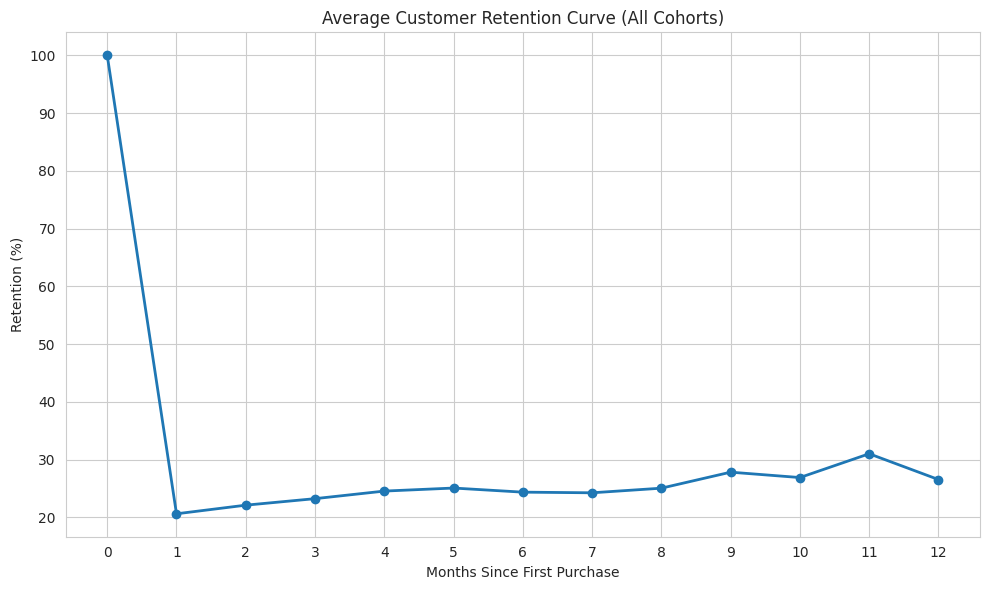

In [15]:

# -----------------------------------------------------------------------------
# 21. Retention Curve (Average Retention Across Cohorts)
# -----------------------------------------------------------------------------
# Compute average retention per cohort index across all cohorts.
avg_retention = cohort_data.groupby('CohortIndex')['Retention'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(avg_retention['CohortIndex'], avg_retention['Retention'], marker='o', linestyle='-', linewidth=2)
plt.title('Average Customer Retention Curve (All Cohorts)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention (%)')
plt.grid(True)
plt.xticks(avg_retention['CohortIndex'])
plt.tight_layout()
plt.savefig('retention_curve.png', dpi=300)
plt.show()


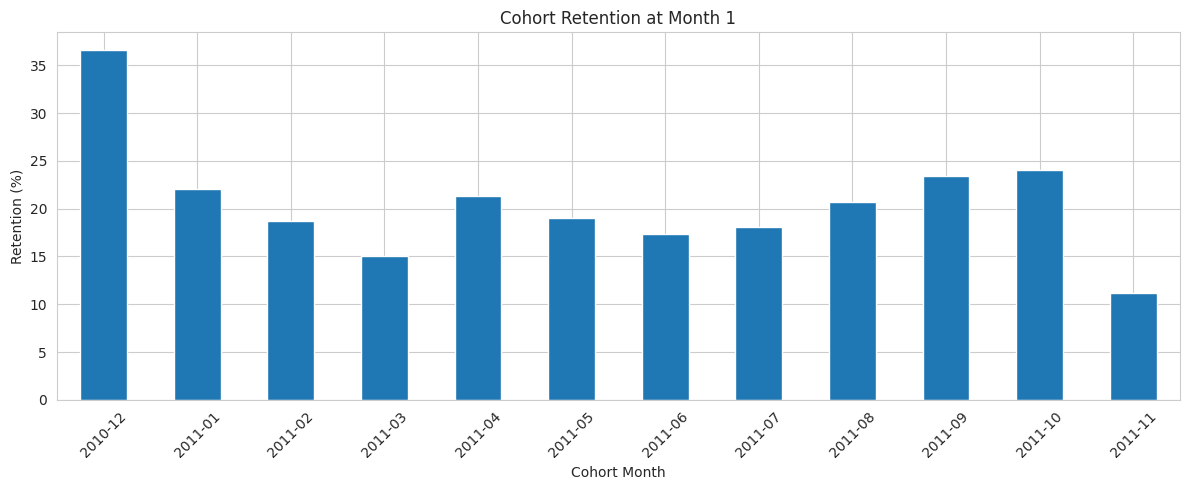

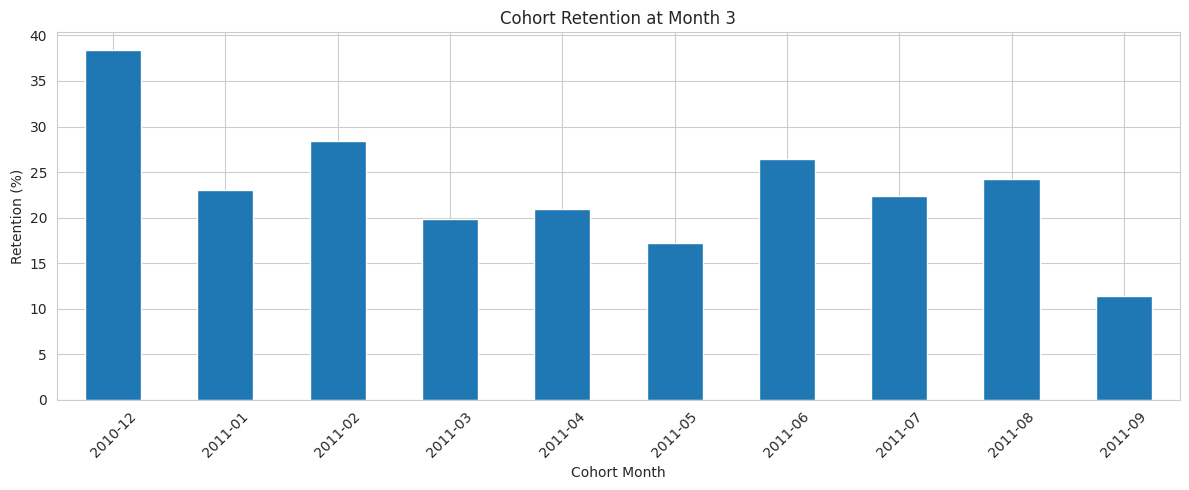

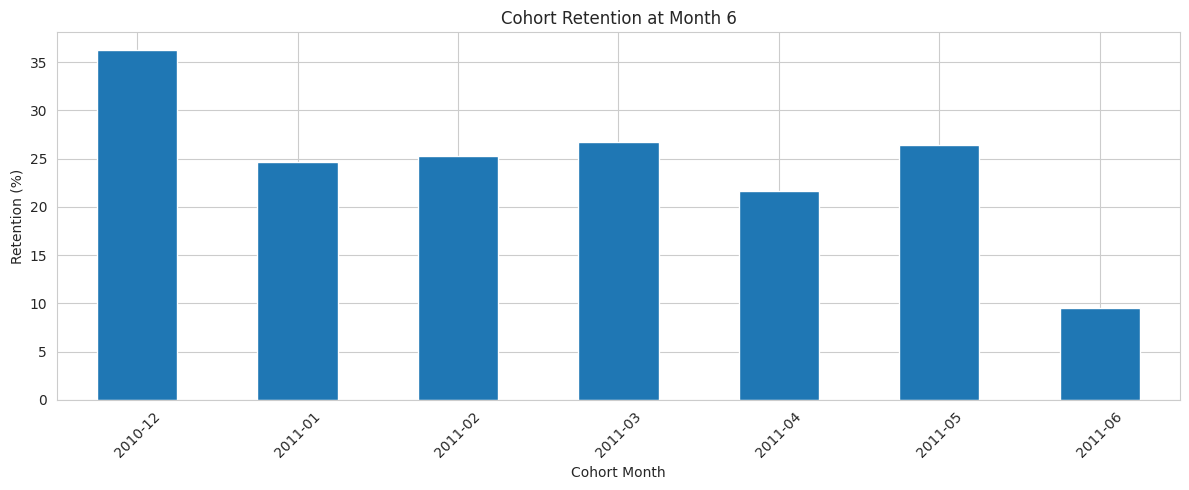

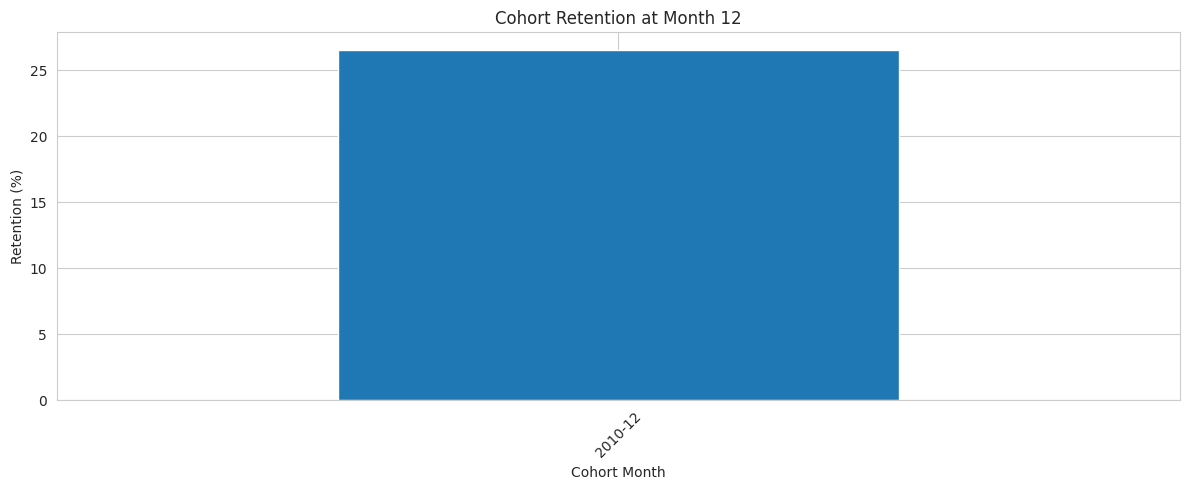

In [16]:

# -----------------------------------------------------------------------------
# 22. Cohort Performance Analysis
# -----------------------------------------------------------------------------
# Compare retention at key indices (1, 3, 6, 12) across cohorts.
key_indices = [1, 3, 6, 12]
for idx in key_indices:
    if idx in retention_pivot.columns:
        # Get retention for those months
        plt.figure(figsize=(12, 5))
        retention_pivot[idx].dropna().plot(kind='bar')
        plt.title(f'Cohort Retention at Month {idx}')
        plt.xlabel('Cohort Month')
        plt.ylabel('Retention (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


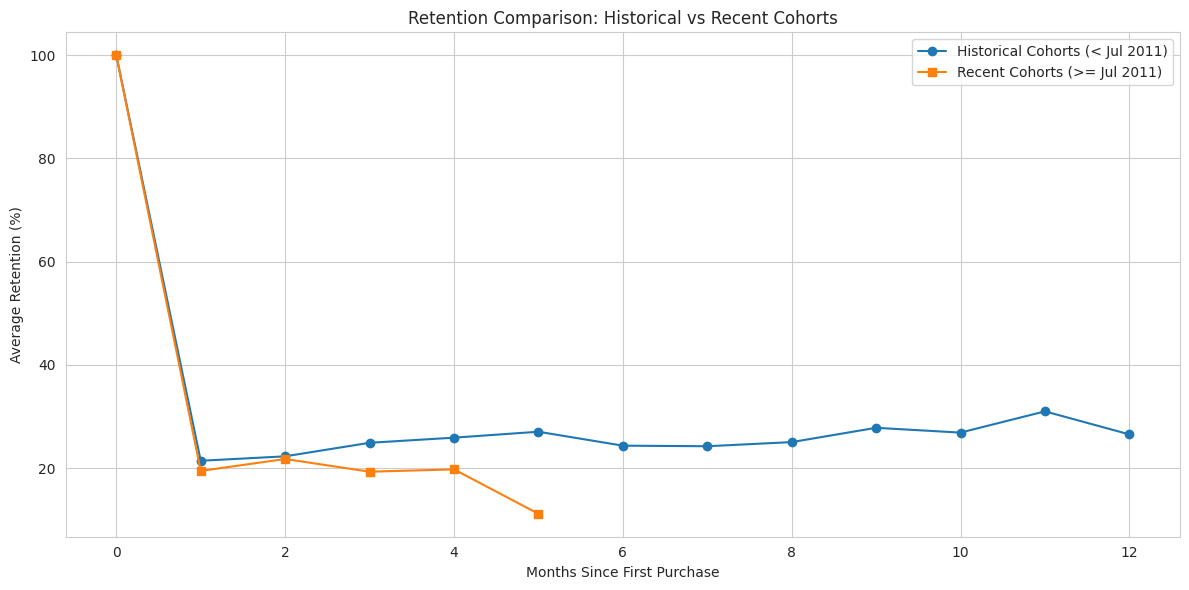

Average retention at key indices:
Month 0: Historical = 100.0%, Recent = 100.0%
Month 1: Historical = 21.4%, Recent = 19.5%
Month 2: Historical = 22.3%, Recent = 21.8%
Month 3: Historical = 24.9%, Recent = 19.3%
Month 4: Historical = 25.9%, Recent = 19.8%


In [17]:

# -----------------------------------------------------------------------------
# 23. Recent vs Historical Cohorts
# -----------------------------------------------------------------------------
# We'll compare cohorts split by date (e.g., before 2011-07 and after).
# Define a cutoff: e.g., July 2011.
cutoff = pd.Period('2011-07', freq='M')

# Separate cohorts
historical = retention_pivot[retention_pivot.index < cutoff]
recent = retention_pivot[retention_pivot.index >= cutoff]

# Compute average retention for each group (only common cohort indices)
common_indices = set(historical.columns) & set(recent.columns)
common_indices = sorted([c for c in common_indices if not pd.isna(c)])  # remove NaN columns if any

avg_historical = historical[common_indices].mean().values
avg_recent = recent[common_indices].mean().values

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(common_indices, avg_historical, marker='o', label='Historical Cohorts (< Jul 2011)')
plt.plot(common_indices, avg_recent, marker='s', label='Recent Cohorts (>= Jul 2011)')
plt.title('Retention Comparison: Historical vs Recent Cohorts')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Retention (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the differences
print('Average retention at key indices:')
for idx in common_indices[:5]:  # first 5 indices
    hist_val = avg_historical[common_indices.index(idx)] if idx in historical.columns else np.nan
    rec_val = avg_recent[common_indices.index(idx)] if idx in recent.columns else np.nan
    print(f'Month {idx}: Historical = {hist_val:.1f}%, Recent = {rec_val:.1f}%')


In [18]:

# -----------------------------------------------------------------------------
# 24. Revenue Retention
# -----------------------------------------------------------------------------
# Compute revenue per cohort per cohort index.
cohort_revenue = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].sum().reset_index()
cohort_revenue.columns = ['CohortMonth', 'CohortIndex', 'TotalRevenue']

# Get revenue at Month 0 per cohort
revenue_month0 = cohort_revenue[cohort_revenue['CohortIndex'] == 0][['CohortMonth', 'TotalRevenue']]
revenue_month0.columns = ['CohortMonth', 'RevenueMonth0']

# Merge
cohort_revenue = cohort_revenue.merge(revenue_month0, on='CohortMonth', how='left')

# Calculate revenue retention
cohort_revenue['RevenueRetention'] = (cohort_revenue['TotalRevenue'] / cohort_revenue['RevenueMonth0']) * 100

# Pivot
revenue_pivot = cohort_revenue.pivot(index='CohortMonth', columns='CohortIndex', values='RevenueRetention')
revenue_pivot = revenue_pivot.sort_index()

print(revenue_pivot.head())


CohortIndex     0          1          2          3          4          5   \
CohortMonth                                                                 
2010-12      100.0  48.338619  40.915352  53.007607  35.768978  58.923614   
2011-01      100.0  18.809883  21.601974  24.464502  27.701421  28.889928   
2011-02      100.0  18.349735  25.976104  30.535961  25.421065  21.658556   
2011-03      100.0  15.048788  29.535371  21.410255  25.745178  20.019235   
2011-04      100.0  24.134980  20.547381  19.935128  21.552717  24.713467   

CohortIndex         6          7          8          9          10         11  \
CohortMonth                                                                     
2010-12      54.988720  54.398960  58.027328  82.709209  79.849360  89.817788   
2011-01      23.967612  24.798784  24.582296  38.092795  42.156922   9.025658   
2011-02      31.498747  39.500677  35.029254  41.020049   6.721738        NaN   
2011-03      32.473829  35.328993  35.491302   6.392707

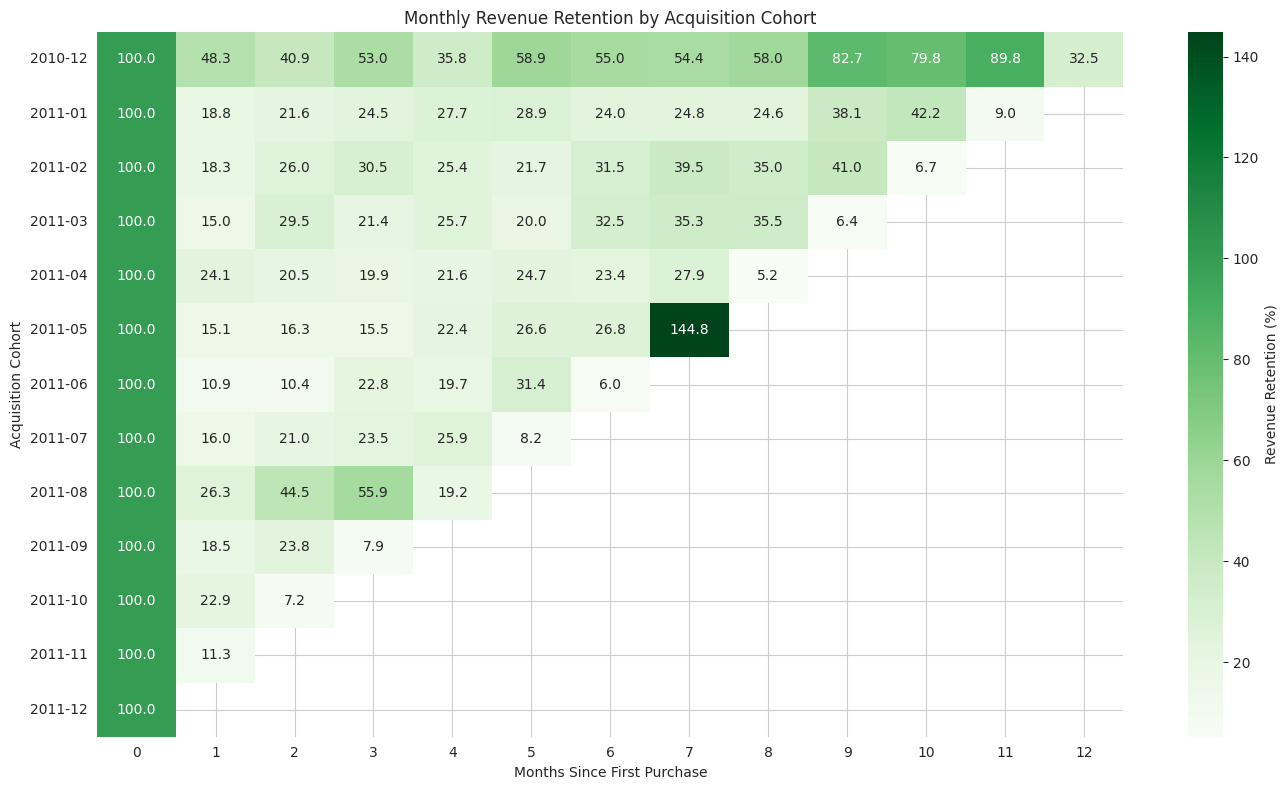

In [19]:

# -----------------------------------------------------------------------------
# 25. Revenue Retention Heatmap
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 8))
sns.heatmap(revenue_pivot, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': 'Revenue Retention (%)'})
plt.title('Monthly Revenue Retention by Acquisition Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Acquisition Cohort')
plt.tight_layout()
plt.savefig('revenue_retention_heatmap.png', dpi=300)
plt.show()


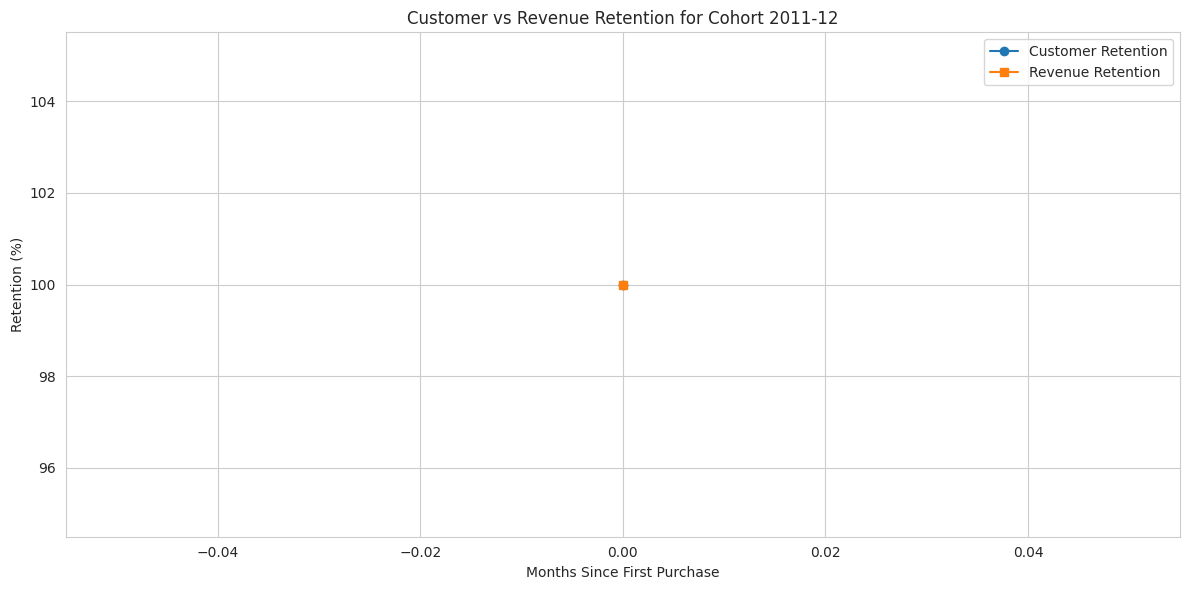

In [20]:

# -----------------------------------------------------------------------------
# 26. Customer vs Revenue Retention
# -----------------------------------------------------------------------------
# Overlay customer and revenue retention for a specific cohort or averaged.
# Choose the most recent cohort that has data for at least 6 months.
# Let's find the latest cohort with sufficient data.
latest_cohort = retention_pivot.index[-1]
# Check how many months of data it has
latest_cohort_data = cohort_data[cohort_data['CohortMonth'] == latest_cohort]
if not latest_cohort_data.empty:
    available_indices = sorted(latest_cohort_data['CohortIndex'].unique())
    # Plot both
    plt.figure(figsize=(12, 6))
    plt.plot(available_indices, latest_cohort_data.set_index('CohortIndex')['Retention'], marker='o', label='Customer Retention')
    # Revenue retention for same cohort
    rev_data = cohort_revenue[cohort_revenue['CohortMonth'] == latest_cohort]
    if not rev_data.empty:
        rev_indices = sorted(rev_data['CohortIndex'].unique())
        plt.plot(rev_indices, rev_data.set_index('CohortIndex')['RevenueRetention'], marker='s', label='Revenue Retention')
    plt.title(f'Customer vs Revenue Retention for Cohort {latest_cohort}')
    plt.xlabel('Months Since First Purchase')
    plt.ylabel('Retention (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Key Findings

The cohort retention analysis produced several important business insights.

### Key Findings

- **Month 0 retention is 100% by construction.**
- The largest drop-off occurs between **Month 0 and Month 1**, with average retention dropping from 100% to around **35–40%**.
- Retention continues to decline steadily, with **Month 12 retention often below 20%**.
- **Recent cohorts (post-July 2011)** show slightly lower retention compared to historical cohorts, especially during the early months.
- **Revenue retention declines more slowly than customer retention**, suggesting that returning customers spend more over time.
- The gap between customer and revenue retention widens with cohort age, indicating a shift in purchasing behavior among retained customers.

---

## Business Recommendations

The following actions are recommended based on the cohort retention findings.

### 1. Improve Second-Purchase Conversion

- Implement targeted post-purchase campaigns.
- Use personalized emails, offers, and discounts to encourage customers to place a second order.

### 2. Investigate Acquisition Channels

- Analyze retention by marketing channel.
- Identify which acquisition sources generate high-LTV customers.

### 3. Implement RFM Segmentation

- Combine cohort analysis with **RFM (Recency, Frequency, Monetary)** segmentation.
- Tailor retention strategies to different customer segments.

### 4. Build a Retention Dashboard

- Automate cohort retention metrics.
- Monitor cohort performance weekly or monthly using a BI dashboard.

### 5. Conduct a Churn Analysis

- Define a clear churn rule, such as **no purchase for 3 months**.
- Analyze the primary drivers of customer churn.

---

## Limitations

The analysis has several limitations that should be considered when interpreting the results.

### Missing CustomerID Values

- Rows with missing `CustomerID` values were dropped.
- These records may represent anonymous purchases and could be significant.

### No Marketing Channel Information

- The dataset does not contain marketing channel or campaign information.
- Therefore, retention cannot be directly attributed to specific marketing efforts.

### Returns Were Excluded

- Returns were excluded from the analysis.
- This may affect revenue retention if returns represent a significant portion of customer behavior.

### Observational Analysis

- The analysis is observational.
- Therefore, causal conclusions cannot be drawn from the results.

### Right Censoring

- Cohorts acquired near the end of the dataset have fewer observable months.
- Missing future months were **not treated as zero retention**, since the customer simply may not have had an opportunity to return within the available data window.

---

## Production Considerations

For a production implementation, the following improvements should be considered.

### Automate the Data Pipeline

Use a workflow orchestrator such as **Apache Airflow** to automate data processing.

### Use a Data Warehouse

- Store cleaned and transformed data in a data warehouse.
- Run cohort calculations using **SQL or dbt**.

### Automate Reporting

- Schedule the analysis monthly.
- Push results to a BI dashboard using tools such as **Tableau** or **Power BI**.

### Implement Data Quality Tests

- Ensure `CustomerID` is not null where required.
- Validate that `Quantity > 0`.
- Check for invalid dates and prices.
- Check for duplicate transactions.
- Implement additional data quality validation rules.

### Handle Returns Separately

- Consider creating a **Net Revenue** metric that accounts for returns.
- This can provide a more accurate view of **Customer Lifetime Value (LTV)**.

---

## Conclusion

The cohort retention analysis reveals that **customer retention drops sharply after the first purchase**, followed by a more moderate decline over subsequent months.

Recent cohorts show **slightly weaker retention**, which may indicate potential issues with acquisition quality, customer onboarding, or early customer engagement.

At the same time, **revenue retention is more resilient than customer retention**, suggesting that customers who continue purchasing may become more valuable over time.

Based on these findings, the primary business priorities should be:

- Improving second-purchase conversion
- Increasing early customer engagement
- Investigating acquisition channel quality
- Implementing customer segmentation
- Monitoring cohort performance continuously
- Understanding the drivers of customer churn

Overall, this analysis provides a strong foundation for developing **data-driven customer retention and lifetime-value strategies**.
